# MKA-MLF, Lab_08 - RNN

Recurrent Neural Networks, are a class of artificial neural networks designed to recognize patterns in sequences of data, such as text, genomes, handwriting, or spoken words. Unlike traditional neural networks, which assume all inputs (and outputs) are independent of each other, RNNs are designed to recognize sequential or temporal patterns, making them especially suited for tasks like language modeling, speech recognition, and time series prediction.

## Exercise 1 - Time Series Forecasting

### 1.0 Import Libraries

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Dense, Flatten, SimpleRNN

### 1.1 Generating dataset

In [36]:
def generate_time_series(batch_size, n_steps):
  freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
  time = np.linspace(0,1,n_steps)

  series = 0.5 * np.sin((time - offsets1) * (freq1*10 + 10))
  series += 0.2 * np.sin((time - offsets2) * (freq2*20 + 20))
  series += 0.1 * (np.random.rand(batch_size, n_steps)- 0.5)
  return series[..., np.newaxis].astype(np.float32)

In [37]:
data_size = 10000
n_steps = 50
np.random.seed(0)

series = generate_time_series(data_size, n_steps + 1)

### 1.2 Train/Valid/Test split

In [38]:
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [39]:
no_training_epochs = 5

### 1.3 Data examination

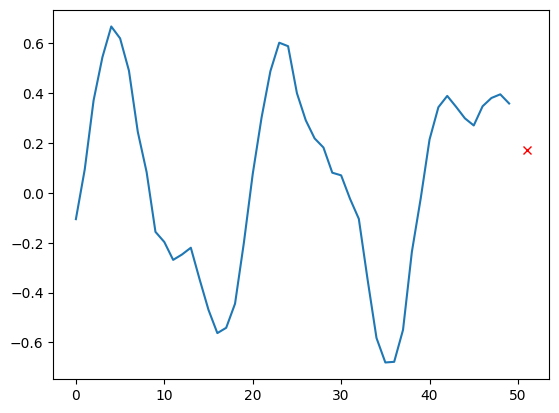

In [40]:
plt.figure()
plt.plot(X_train[0])
plt.plot(n_steps+1, y_train[0], 'rx')

### 1.4 Simple Linear model

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Flatten, SimpleRNN
from keras.optimizers import Adam

In [42]:
model_linear = Sequential()
model_linear.add(Flatten(input_shape=(50, 1)))
model_linear.add(Dense(1, activation=None))

learning_rate = 0.001
optimizer = Adam(learning_rate)
model_linear.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mean_squared_error'])

In [43]:
model_linear.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [44]:
# Model training

history_linear = model_linear.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1795 - mean_squared_error: 0.1795 - val_loss: 0.0858 - val_mean_squared_error: 0.0858
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0624 - mean_squared_error: 0.0624 - val_loss: 0.0476 - val_mean_squared_error: 0.0476
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0377 - mean_squared_error: 0.0377 - val_loss: 0.0295 - val_mean_squared_error: 0.0295
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0251 - mean_squared_error: 0.0251 - val_loss: 0.0204 - val_mean_squared_error: 0.0204
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0184 - mean_squared_error: 0.0184 - val_loss: 0.0155 - val_mean_squared_error: 0.0155


In [45]:
def plot_function(history):
  plt.figure()

  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='validation_loss')
  plt.legend()
  plt.grid()
  plt.xlim([0,no_training_epochs-1])
  plt.xlabel('epochs')

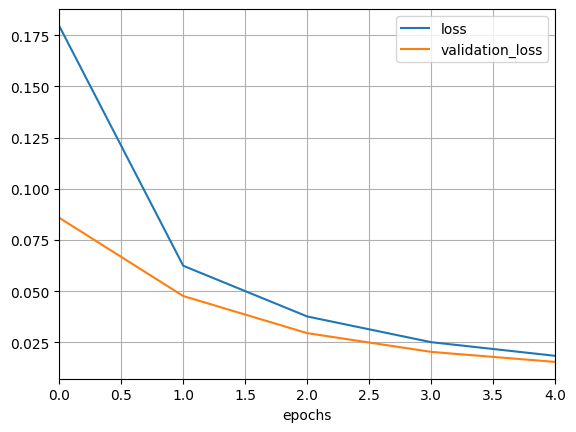

In [46]:
plot_function(history_linear)

In [47]:
score = model_linear.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.015916084870696068
Test MSE:  0.015916084870696068


### 1.5 Simple RNN Model

In [48]:
model_simple_rnn = Sequential()
model_simple_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [49]:
learning_rate_simple_rnn = 0.001
optimizer_simple_rnn = Adam(learning_rate_simple_rnn)
model_simple_rnn.compile(loss='mean_squared_error', optimizer=optimizer_simple_rnn, metrics=['mean_squared_error'])

In [50]:
history_simple_rnn = model_simple_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.4525 - mean_squared_error: 0.4525 - val_loss: 0.3062 - val_mean_squared_error: 0.3062
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2642 - mean_squared_error: 0.2642 - val_loss: 0.2622 - val_mean_squared_error: 0.2622
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2237 - mean_squared_error: 0.2237 - val_loss: 0.2179 - val_mean_squared_error: 0.2179
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1839 - mean_squared_error: 0.1839 - val_loss: 0.1744 - val_mean_squared_error: 0.1744
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1513 - mean_squared_error: 0.1513 - val_loss: 0.1459 - val_mean_squared_error: 0.1459


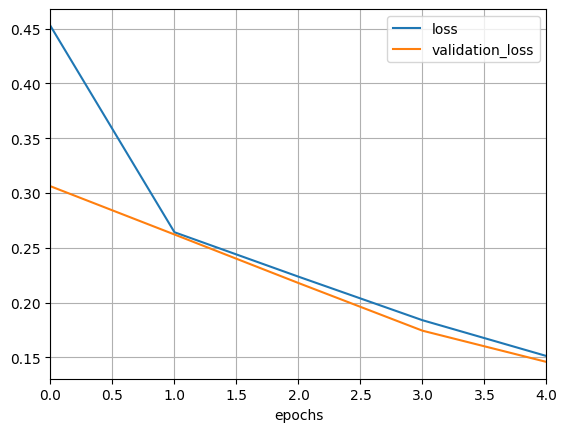

In [51]:
plot_function(history_simple_rnn)

### 1.5 Deep RNN Model

In [52]:
model_deep_rnn = Sequential()
model_deep_rnn.add(SimpleRNN(20, return_sequences = True, input_shape=[50, 1]))
model_deep_rnn.add(SimpleRNN(20, return_sequences = True))
model_deep_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

In [53]:
learning_rate_deep_rnn = 0.001
optimizer_deep_rnn = Adam(learning_rate_deep_rnn)
model_deep_rnn.compile(loss='mean_squared_error', optimizer=optimizer_deep_rnn, metrics=['mean_squared_error'])

In [54]:
history_deep_rnn = model_deep_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.0529 - mean_squared_error: 0.0529 - val_loss: 0.0086 - val_mean_squared_error: 0.0086
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0068 - mean_squared_error: 0.0068 - val_loss: 0.0056 - val_mean_squared_error: 0.0056
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0048 - mean_squared_error: 0.0048 - val_loss: 0.0064 - val_mean_squared_error: 0.0064
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0041 - mean_squared_error: 0.0041 - val_loss: 0.0037 - val_mean_squared_error: 0.0037
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0038 - mean_squared_error: 0.0038 - val_loss: 0.0044 - val_mean_squared_error: 0.0044


In [55]:
score = model_deep_rnn.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.004222885239869356
Test MSE:  0.004222885239869356


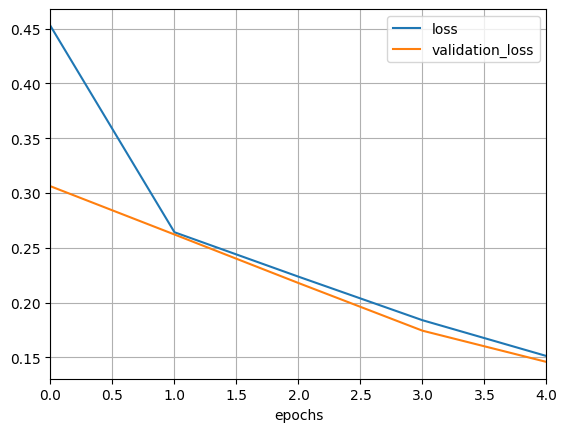

In [56]:
plot_function(history_simple_rnn)

## Exercise 2 - The movie review




Based on the written rewiev, classify if the movie if good or bad

### 2.0 - Import libraries

In [57]:
import keras
import numpy as np
from keras.models import Sequential
from keras.layers import LSTM, Dense, Embedding, SimpleRNN, GRU
import matplotlib.pyplot as plt
from keras.optimizers import Adam

### 2.1 - Load dataset

In [58]:
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data()

### 2.2 - Dataset examination

In [59]:
word_index = keras.datasets.imdb.get_word_index()
id_to_word = {id_ + 3:word for word, id_ in word_index.items()}
for id_, token in enumerate(("<pad>", "<sos>", "<unk>")):
  id_to_word[id_] = token

In [61]:
single_sequence = " ".join([id_to_word[id_] for id_ in X_train[0][:]])

In [62]:
single_sequence

"<sos> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and shou

In [63]:
max_length = 150  # Define the maximum length of a review
X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post', value=0)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post', value=0)

In [64]:
embed_size = 128
vocabulary_size = 1000

model = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size,
                           input_shape=[None]),
    keras.layers.SimpleRNN(128, return_sequences=True),
    keras.layers.SimpleRNN(128),
    keras.layers.Dense(1, activation='sigmoid')
    ])


In [65]:
optimizer = Adam(learning_rate = 0.001)

In [66]:
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [67]:
history = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.5009 - loss: 0.7062 - val_accuracy: 0.4938 - val_loss: 0.6971
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.5042 - loss: 0.6954 - val_accuracy: 0.4938 - val_loss: 0.6934
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.4970 - loss: 0.6957 - val_accuracy: 0.5062 - val_loss: 0.6976
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.4961 - loss: 0.6957 - val_accuracy: 0.5062 - val_loss: 0.6979
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.4988 - loss: 0.6957 - val_accuracy: 0.5062 - val_loss: 0.6937


In [68]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test accuracy: ', score[1]*100, "%")

Test loss: 0.6943173408508301
Test accuracy:  50.0 %


TASK: Modify structure, change the core of the network from RNN to LTSM and GRU. Compare the results

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, None, 128)      │       128,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_10 (SimpleRNN)       │ (None, None, 128)      │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_11 (SimpleRNN)       │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193,921 (757.50 KB)

 Trainable params: 193,921 (757.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.5044 - loss: 0.7175 - val_accuracy: 0.4938 - val_loss: 0.7089
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.5002 - loss: 0.6969 - val_accuracy: 0.4938 - val_loss: 0.6939
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.4985 - loss: 0.6958 - val_accuracy: 0.4938 - val_loss: 0.6933
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.5006 - loss: 0.6961 - val_accuracy: 0.4938 - val_loss: 0.6958
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.5025 - loss: 0.6965 - val_accuracy: 0.4938 - val_loss: 0.6966
SimpleRNN - Test loss: 0.6957019567489624
SimpleRNN - Test accuracy: 50.0 %


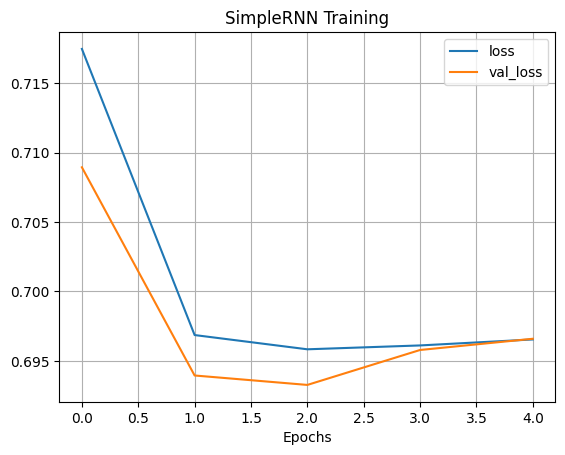

In [69]:
#RNN
model_rnn = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size, input_shape=[None]),
    keras.layers.SimpleRNN(128, return_sequences=True),
    keras.layers.SimpleRNN(128),
    keras.layers.Dense(1, activation='sigmoid')
])

optimizer_rnn = Adam(learning_rate=0.001)
model_rnn.compile(loss="binary_crossentropy", optimizer=optimizer_rnn, metrics=["accuracy"])
model_rnn.summary()

history_rnn = model_rnn.fit(X_train, y_train, epochs=5, validation_split=0.2)

score_rnn = model_rnn.evaluate(X_test, y_test, verbose=0)
print('SimpleRNN - Test loss:', score_rnn[0])
print('SimpleRNN - Test accuracy:', score_rnn[1] * 100, "%")

# Training plot
plt.figure()
plt.plot(history_rnn.history['loss'], label='loss')
plt.plot(history_rnn.history['val_loss'], label='val_loss')
plt.title('SimpleRNN Training')
plt.xlabel('Epochs')
plt.legend()
plt.grid()
plt.show()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, None, 128)      │       128,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, None, 128)      │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391,297 (1.49 MB)

 Trainable params: 391,297 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.5501 - loss: 0.6842 - val_accuracy: 0.4972 - val_loss: 0.6940
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.5586 - loss: 0.6802 - val_accuracy: 0.4938 - val_loss: 0.7061
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.5417 - loss: 0.6833 - val_accuracy: 0.5360 - val_loss: 0.6886
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.5642 - loss: 0.6797 - val_accuracy: 0.6748 - val_loss: 0.6383
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7638 - loss: 0.4979 - val_accuracy: 0.7986 - val_loss: 0.4346
LSTM - Test loss: 0.4237508177757263
LSTM - Test accuracy: 80.64000010490417 %


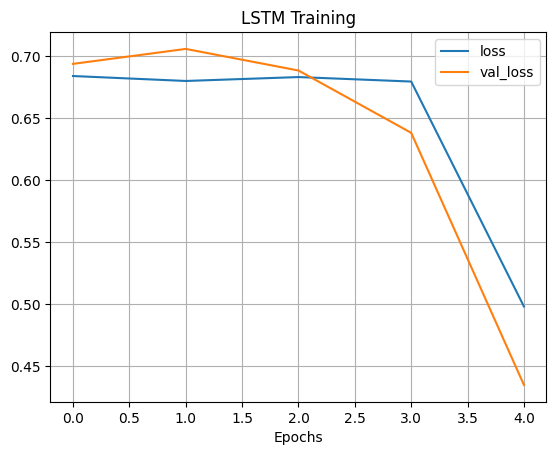

In [70]:
#LSTM
model_lstm = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size, input_shape=[None]),
    keras.layers.LSTM(128, return_sequences=True),
    keras.layers.LSTM(128),
    keras.layers.Dense(1, activation='sigmoid')
])

optimizer_lstm = Adam(learning_rate=0.001)
model_lstm.compile(loss="binary_crossentropy", optimizer=optimizer_lstm, metrics=["accuracy"])
model_lstm.summary()

history_lstm = model_lstm.fit(X_train, y_train, epochs=5, validation_split=0.2)

score_lstm = model_lstm.evaluate(X_test, y_test, verbose=0)
print('LSTM - Test loss:', score_lstm[0])
print('LSTM - Test accuracy:', score_lstm[1] * 100, "%")

# Training plot
plt.figure()
plt.plot(history_lstm.history['loss'], label='loss')
plt.plot(history_lstm.history['val_loss'], label='val_loss')
plt.title('LSTM Training')
plt.xlabel('Epochs')
plt.legend()
plt.grid()
plt.show()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, None, 128)      │       128,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, None, 128)      │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 326,273 (1.24 MB)

 Trainable params: 326,273 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.5707 - loss: 0.6670 - val_accuracy: 0.7240 - val_loss: 0.5563
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.7745 - loss: 0.4806 - val_accuracy: 0.8092 - val_loss: 0.4235
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8284 - loss: 0.3790 - val_accuracy: 0.8138 - val_loss: 0.4103
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8318 - loss: 0.3749 - val_accuracy: 0.8292 - val_loss: 0.3827
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8508 - loss: 0.3364 - val_accuracy: 0.8298 - val_loss: 0.3891
GRU - Test loss: 0.3746480941772461
GRU - Test accuracy: 83.38800072669983 %


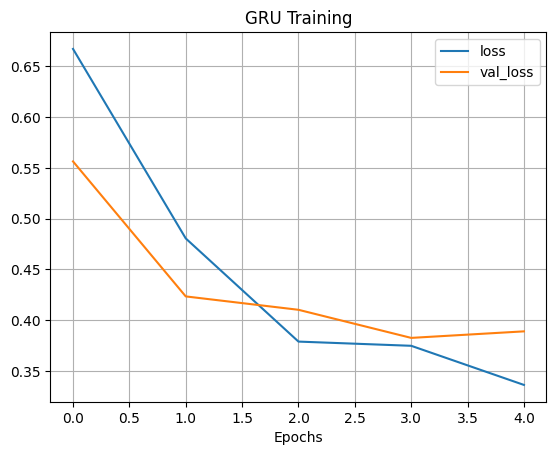

In [71]:
#GRU
model_gru = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size, input_shape=[None]),
    keras.layers.GRU(128, return_sequences=True),
    keras.layers.GRU(128),
    keras.layers.Dense(1, activation='sigmoid')
])

optimizer_gru = Adam(learning_rate=0.001)
model_gru.compile(loss="binary_crossentropy", optimizer=optimizer_gru, metrics=["accuracy"])
model_gru.summary()

history_gru = model_gru.fit(X_train, y_train, epochs=5, validation_split=0.2)

score_gru = model_gru.evaluate(X_test, y_test, verbose=0)
print('GRU - Test loss:', score_gru[0])
print('GRU - Test accuracy:', score_gru[1] * 100, "%")

# Training plot
plt.figure()
plt.plot(history_gru.history['loss'], label='loss')
plt.plot(history_gru.history['val_loss'], label='val_loss')
plt.title('GRU Training')
plt.xlabel('Epochs')
plt.legend()
plt.grid()
plt.show()

Model           Test Loss    Test Accuracy
SimpleRNN          0.6957           50.00%
LSTM               0.4238           80.64%
GRU                0.3746           83.39%


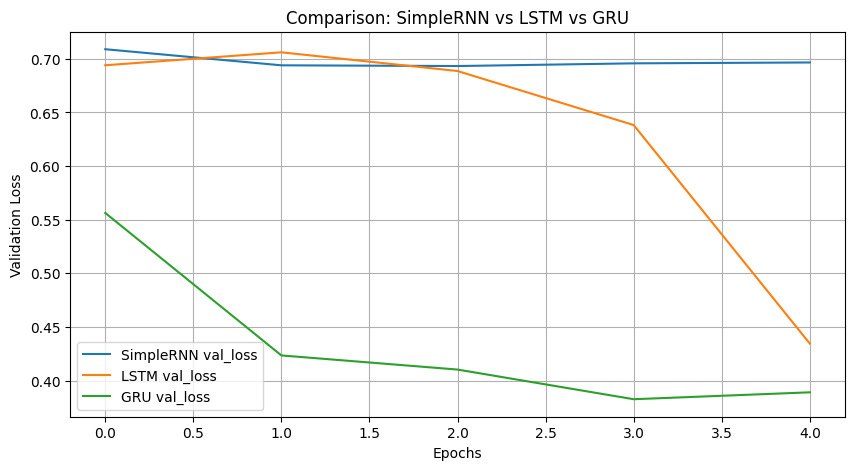

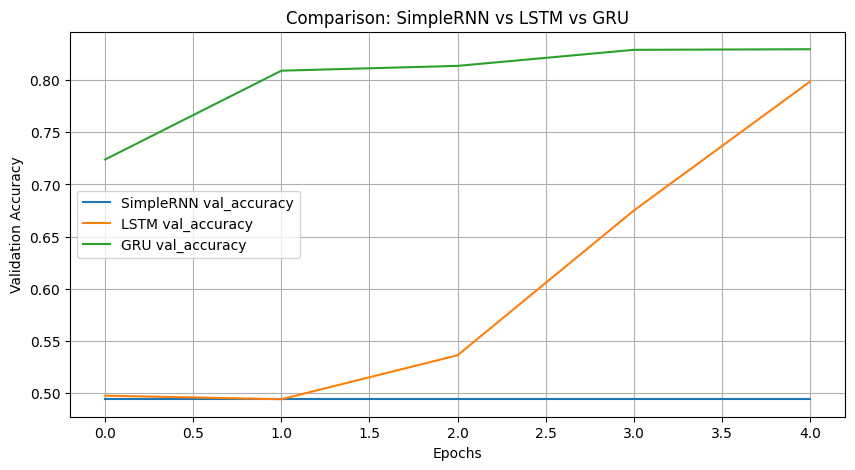

In [72]:
print("=" * 52)
print(f"{'Model':<12} {'Test Loss':>12} {'Test Accuracy':>16}")
print("=" * 52)
print(f"{'SimpleRNN':<12} {score_rnn[0]:>12.4f} {score_rnn[1]*100:>15.2f}%")
print(f"{'LSTM':<12} {score_lstm[0]:>12.4f} {score_lstm[1]*100:>15.2f}%")
print(f"{'GRU':<12} {score_gru[0]:>12.4f} {score_gru[1]*100:>15.2f}%")
print("=" * 52)

# Comparative validation loss plot
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['val_loss'],  label='SimpleRNN val_loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM val_loss')
plt.plot(history_gru.history['val_loss'],  label='GRU val_loss')
plt.title('Comparison: SimpleRNN vs LSTM vs GRU')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid()
plt.show()

# Comparative validation accuracy plot
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['val_accuracy'],  label='SimpleRNN val_accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM val_accuracy')
plt.plot(history_gru.history['val_accuracy'],  label='GRU val_accuracy')
plt.title('Comparison: SimpleRNN vs LSTM vs GRU')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid()
plt.show()